# Simon's Algorithm
The oracle hides a period $s$ with $f(x)=f(x\oplus s)$ (a 2-to-1 function). Unlike Deutsch-Jozsa / Bernstein-Vazirani, one run isn't enough:
each measurement returns a $y$ satisfying $y\cdot s = 0 \bmod 2$. Collect ~$n{-}1$ independent $y$'s, then solve the linear system over GF(2) to get $s$.
Same hardware setup as before — real backend and a noise-matched simulator, in parallel.

In [28]:
# Connect to IBM Quantum (account already saved earlier)
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

In [29]:
# Pick the real backend and build a Sampler bound to it
from qiskit_ibm_runtime import SamplerV2 as Sampler

backend = service.backend("ibm_marrakesh")
sampler = Sampler(mode=backend)
print(backend.name)

ibm_marrakesh


In [30]:
# Build a local Aer simulator that mimics the backend's noise
from qiskit.primitives import BackendSamplerV2
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [31]:
# Oracle: copy input->output (makes it 2-to-1), then imprint the period s
from qiskit import QuantumCircuit

def simon_oracle(s: str) -> QuantumCircuit:
    n = len(s)
    oracle = QuantumCircuit(2 * n)
    for i in range(n):
        oracle.cx(i, n + i)                 # copy input register into output register
    idx = [i for i, b in enumerate(reversed(s)) if b == "1"]
    if idx:
        j = idx[0]                          # control on the lowest set bit of s
        for i in idx:
            oracle.cx(j, n + i)
    return oracle

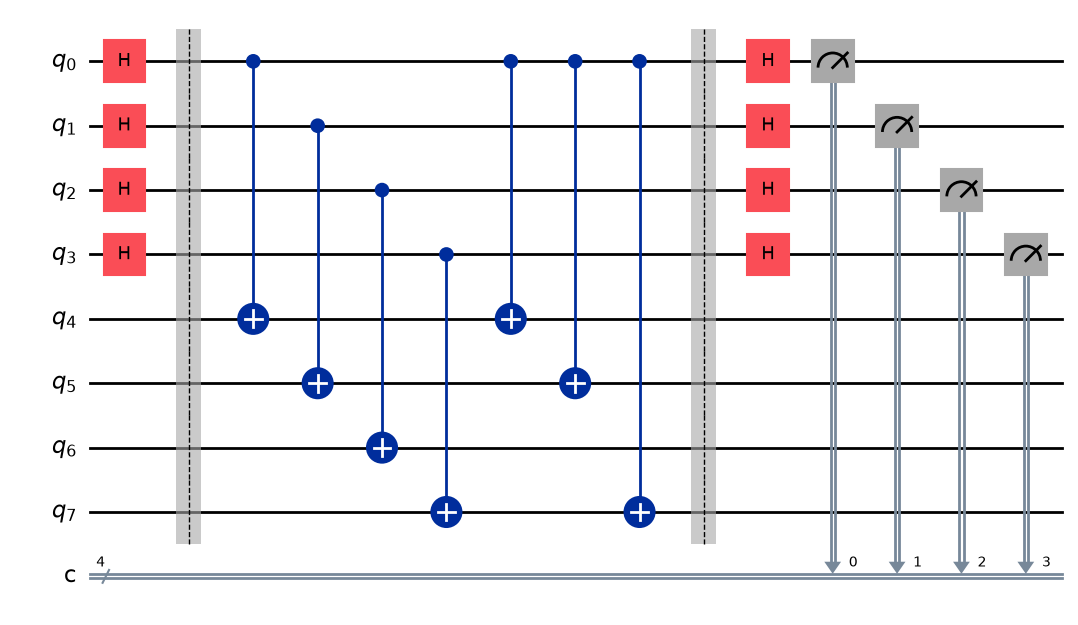

In [32]:
# Assemble the full Simon circuit (2n qubits, measure only the input register) and draw it
s = "1011"                       # the secret period to recover
n = len(s)

qc = QuantumCircuit(2 * n, n)
qc.h(range(n))                   # superposition over all inputs
qc.barrier()
qc.compose(simon_oracle(s), inplace=True)
qc.barrier()
qc.h(range(n))                   # interference: each outcome y obeys y.s = 0
qc.measure(range(n), range(n))

qc.draw("mpl")

In [33]:
# Transpile to the backend's native gates/qubits (ISA circuit)
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)

In [34]:
# Submit both jobs first so they run in parallel, then collect results
job_real = sampler.run([qc_isa], shots=1024)
job_sim = sampler_sim.run([qc_isa], shots=1024)

counts_real = job_real.result()[0].data.c.get_counts()
counts_sim = job_sim.result()[0].data.c.get_counts()

In [35]:
# Classical post-processing: pick the nonzero s that the most shots agree with (y.s = 0).
# Robust to noise, unlike Gaussian elimination where one bad equation derails the answer.
def recover_s(counts, n):
    best_s, best_score = None, -1
    for cand in range(1, 2 ** n):
        s = format(cand, f"0{n}b")
        score = sum(c for y, c in counts.items()
                    if sum(int(a) & int(b) for a, b in zip(y, s)) % 2 == 0)
        if score > best_score:
            best_s, best_score = s, score
    return best_s

secret s : 1011
from sim  : 1011
from real : 1011


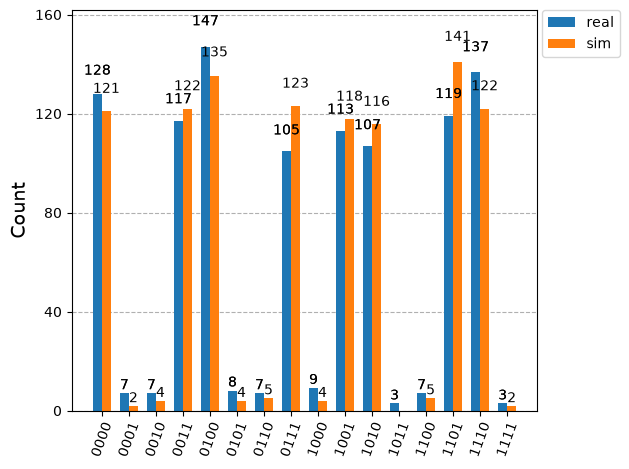

In [36]:
# Recover s from each run and compare against the histograms
from qiskit.visualization import plot_histogram

print("secret s :", s)
print("from sim  :", recover_s(counts_sim, n))
print("from real :", recover_s(counts_real, n))
plot_histogram([counts_real, counts_sim], legend=["real", "sim"])